# 04 — Force-Directed Graph Export

**Goal:** export the community-detected graph as a D3 / Cytoscape-friendly JSON file that the case-study frontend prototype can consume.

**Inputs:** `data/interim/cooccurrence_edges.parquet`, `data/interim/communities.parquet`, `data/interim/articles_clean.parquet`
**Outputs:** `design/graph/style-clusters.json`

**Design contract — what the JSON consumer expects:**
```json
{
  "nodes": [{"id": "sku", "label": "Trousers / Denim", "community": 3, "colour": "#1f77b4", "size": 12}, ...],
  "links": [{"source": "sku_a", "target": "sku_b", "weight": 2.4}, ...],
  "communities": [{"id": 3, "label": "Light denim · cross-category", "colour": "#1f77b4", "size": 47}, ...],
  "meta": {"generated_at": "...", "source": "H&M proxy — see data/methodology.md", ...}
}
```

**Pruning logic:** force-directed graphs become illegible past ~200 nodes. We keep the top-K communities by size, sample within each community by node degree, cap total at ~150 nodes. This is the **viz** export, not the analysis export — see notebooks 02/03 for the full result set.

## 1 · Setup + load everything

In [1]:
import json
import datetime as dt
from pathlib import Path
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.cm as cm
import matplotlib.colors as mcolors

INTERIM = Path('../interim')
OUT_DIR = Path('../../design/graph')
OUT_DIR.mkdir(parents=True, exist_ok=True)

edges = pd.read_parquet(INTERIM / 'cooccurrence_edges.parquet')
comms = pd.read_parquet(INTERIM / 'communities.parquet')
summary = pd.read_parquet(INTERIM / 'community_summary.parquet')
articles = pd.read_parquet(INTERIM / 'articles_clean.parquet')
print(f"Edges: {len(edges):,}, community assignments: {len(comms):,}, communities: {len(summary):,}")

Edges: 8,603, community assignments: 1,939, communities: 65


## 2 · Pruning — pick the communities and SKUs that go into the viz

Two-stage prune:
1. Top K communities by size (ensures the viz tells a coherent story rather than a dust of singletons)
2. Within each community, top-N nodes by degree (the central / representative SKUs)

In [2]:
TOP_K_COMMUNITIES = 8
MAX_NODES_PER_COMMUNITY = 20
MAX_TOTAL_NODES = 150  # force-directed viz starts to collapse past ~200

# Stage 1: pick communities by size, but prefer ones that span 2+ garment groups (the case-study claim)
candidate_summary = summary[summary['n_garment_groups'] >= 2].copy()
if len(candidate_summary) < TOP_K_COMMUNITIES:
    # Fall back to any communities if too few cross-category — flag for the case study
    print(f"⚠️ Only {len(candidate_summary)} cross-category communities found; padding with single-category communities.")
    candidate_summary = summary.copy()

top_communities = candidate_summary.head(TOP_K_COMMUNITIES)['community'].tolist()
print(f"Keeping {len(top_communities)} communities: {top_communities}")

Keeping 8 communities: [30, 11, 53, 5, 29, 45, 17, 2]


In [3]:
# Stage 2: per-community node degree. Build the full graph first so degree is well-defined.
G_full = nx.from_pandas_edgelist(edges, 'source', 'target', edge_attr='lift', create_using=nx.Graph())

kept_nodes = []
for cid in top_communities:
    members = comms[comms['community'] == cid]['article_id'].tolist()
    members_in_graph = [m for m in members if m in G_full]
    # Sort by weighted degree (sum of incident lift)
    deg = sorted(
        ((m, sum(d.get('lift', 1.0) for d in G_full[m].values())) for m in members_in_graph),
        key=lambda x: x[1],
        reverse=True,
    )
    kept = [m for m, _ in deg[:MAX_NODES_PER_COMMUNITY]]
    kept_nodes.extend(kept)

# Global cap — keep highest-degree across selected
if len(kept_nodes) > MAX_TOTAL_NODES:
    deg_all = sorted(
        ((n, sum(d.get('lift', 1.0) for d in G_full[n].values())) for n in kept_nodes),
        key=lambda x: x[1],
        reverse=True,
    )
    kept_nodes = [n for n, _ in deg_all[:MAX_TOTAL_NODES]]

kept_set = set(kept_nodes)
print(f"Kept {len(kept_nodes)} nodes for the viz")

Kept 150 nodes for the viz


## 3 · Subgraph + edge filtering

In [4]:
G_viz = G_full.subgraph(kept_set).copy()
print(f"Viz subgraph: {G_viz.number_of_nodes()} nodes, {G_viz.number_of_edges()} edges")

# Optional: prune within-subgraph edges below a lift threshold to declutter
EDGE_LIFT_FLOOR = 1.5
low_lift_edges = [(u, v) for u, v, d in G_viz.edges(data=True) if d.get('lift', 0) < EDGE_LIFT_FLOOR]
G_viz.remove_edges_from(low_lift_edges)
print(f"After lift-floor prune (>={EDGE_LIFT_FLOOR}): {G_viz.number_of_edges()} edges")

Viz subgraph: 150 nodes, 495 edges
After lift-floor prune (>=1.5): 495 edges


## 4 · Build the JSON payload

Per the design contract at the top. Colours assigned deterministically from `matplotlib.cm.tab20` so the viz can be regenerated with stable hues across iterations.

In [5]:
def hex_for_index(i):
    return mcolors.to_hex(cm.tab20(i % 20))

comm_colour = {cid: hex_for_index(i) for i, cid in enumerate(top_communities)}

art_lookup = articles.set_index('article_id')
comm_lookup = comms.set_index('article_id')['community'].to_dict()

# --- Distinctive-colour computation ---
# H&M catalog skews heavily toward Black, so ~7 of 8 communities have "Black" as modal colour.
# Modal colour is therefore useless for differentiating communities. Instead compute the
# colour that is most OVER-REPRESENTED in each community vs the graph baseline:
#   distinctive_colour = argmax_c [ P(c | community) / P(c | graph) ]
# This surfaces the colour signal that actually characterises the community (TF-IDF-style).

graph_node_meta = comms[comms['article_id'].isin(set(comm_lookup.keys()))]
graph_colour_pct = graph_node_meta['colour_group_name'].value_counts(normalize=True)

def distinctive_colour_for(cid):
    """Return (colour_name, share_within_community, lift_vs_graph) or (None, 0, 0)."""
    members = comms[comms['community'] == cid]
    if len(members) == 0:
        return None, 0.0, 0.0
    comm_pct = members['colour_group_name'].value_counts(normalize=True)
    # Need at least 3 SKUs of a colour to call it distinctive — avoids 1-SKU noise
    counts = members['colour_group_name'].value_counts()
    eligible = counts[counts >= 3].index
    if len(eligible) == 0:
        # fall back to modal colour
        top = comm_pct.idxmax()
        return top, float(comm_pct[top]), 1.0
    lift = (comm_pct[eligible] / graph_colour_pct.reindex(eligible)).dropna()
    if len(lift) == 0:
        top = comm_pct.idxmax()
        return top, float(comm_pct[top]), 1.0
    top = lift.idxmax()
    return top, float(comm_pct[top]), float(lift[top])

# --- Nodes ---
nodes = []
for n in G_viz.nodes():
    cid = comm_lookup.get(n)
    meta_row = art_lookup.loc[n] if n in art_lookup.index else None
    label = (
        f"{meta_row['product_type_name']} · {meta_row['colour_group_name']}"
        if meta_row is not None else n
    )
    deg_weighted = sum(d.get('lift', 1.0) for d in G_viz[n].values())
    nodes.append({
        'id': n,
        'label': label,
        'community': int(cid) if cid is not None else -1,
        'colour': comm_colour.get(cid, '#888888'),
        'size': float(deg_weighted),
        'garment_group': str(meta_row['garment_group_name']) if meta_row is not None else None,
        'colour_group': str(meta_row['colour_group_name']) if meta_row is not None else None,
    })

# --- Links ---
links = [
    {'source': u, 'target': v, 'weight': float(d.get('lift', 1.0))}
    for u, v, d in G_viz.edges(data=True)
]

# --- Community blocks with smart labels ---
# Label lead = garment_group (varies meaningfully); demote colour to distinctive metric.
community_blocks = []
for cid in top_communities:
    row = summary[summary['community'] == cid].iloc[0]
    dist_colour, dist_share, dist_lift = distinctive_colour_for(cid)
    # Label: "Trousers Denim · 4 groups · 70 SKUs · Blue +6.0×"
    parts = [
        str(row['modal_garment']),
        f"{int(row['n_garment_groups'])} groups",
        f"{int(row['size'])} SKUs",
    ]
    if dist_colour and dist_lift >= 1.2:
        parts.append(f"{dist_colour} +{dist_lift:.1f}×")
    label = " · ".join(parts)

    community_blocks.append({
        'id': int(cid),
        'label': label,
        'colour': comm_colour[cid],
        'size': int(row['size']),
        'n_garment_groups': int(row['n_garment_groups']),
        'modal_colour': str(row['modal_colour']),
        'modal_garment': str(row['modal_garment']),
        'distinctive_colour': str(dist_colour) if dist_colour else None,
        'distinctive_colour_share': round(dist_share, 3),
        'distinctive_colour_lift': round(dist_lift, 2),
    })

# Print summary table for inspection
print(f"{'#':>3} {'community':>9} {'size':>5} {'n_grp':>5} {'modal_garment':<22} {'modal_colour':<14} {'distinctive':<14} {'lift':>6}")
print('-' * 88)
for cb in community_blocks:
    print(f"{cb['id']:>3} {cb['id']:>9} {cb['size']:>5} {cb['n_garment_groups']:>5} "
          f"{cb['modal_garment']:<22} {cb['modal_colour']:<14} "
          f"{str(cb['distinctive_colour']):<14} {cb['distinctive_colour_lift']:>6.2f}")

payload = {
    'nodes': nodes,
    'links': links,
    'communities': community_blocks,
    'meta': {
        'generated_at': dt.datetime.now().isoformat(timespec='seconds'),
        'source': 'H&M Kaggle dataset (proxy for Zalando — see data/methodology.md)',
        'window_days': 30,
        'edge_method': 'sparse_cooccurrence_then_louvain',
        'edge_min_cooccurrence': 10,
        'edge_min_lift': 1.5,
        'louvain_resolution': 1.0,
        'distinctive_colour_method': 'argmax over P(c|comm)/P(c|graph), min 3 SKUs per colour',
        'distinctive_colour_label_threshold': 1.2,
        'n_top_communities_shown': len(top_communities),
        'max_nodes_per_community': MAX_NODES_PER_COMMUNITY,
        'total_nodes': len(nodes),
        'total_links': len(links),
    },
}

out_path = OUT_DIR / 'style-clusters.json'
with open(out_path, 'w') as f:
    json.dump(payload, f, indent=2)
sz = out_path.stat().st_size / 1024
print(f"\nWrote {out_path} ({sz:.1f} KB)")
print(f"  {len(nodes)} nodes, {len(links)} links, {len(community_blocks)} communities")

  # community  size n_grp modal_garment          modal_colour   distinctive      lift
----------------------------------------------------------------------------------------
 30        30   151    13 Knitwear               Black          Light Purple     2.75
 11        11   151     3 Jersey Fancy           Black          Greyish Beige    5.50
 53        53   142     7 Blouses                Black          Dark Orange      4.55
  5         5   113     3 Jersey Basic           Black          Light Purple     4.90
 29        29   100     6 Knitwear               Black          Off White        2.63
 45        45    92     4 Trousers Denim         Black          Dark Blue        6.32
 17        17    70     4 Trousers Denim         Blue           Light Blue      10.21
  2         2    66     6 Blouses                Black          Greenish Khaki   3.01

Wrote ../../design/graph/style-clusters.json (89.6 KB)
  150 nodes, 495 links, 8 communities


## 5 · Quick layout preview

matplotlib-based spring layout so you can sanity-check the structure before handing off to D3. The actual case-study viz is rendered in the frontend (D3 or Cytoscape) — this is just a fast eyeball check.

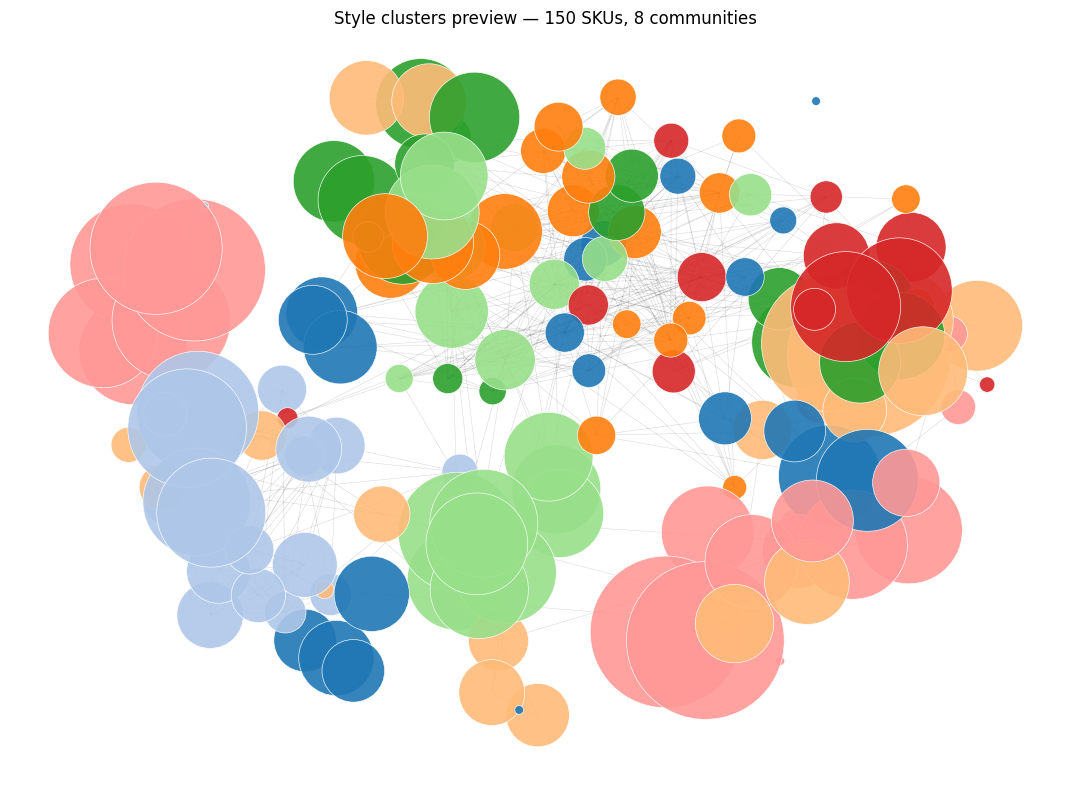

Preview also saved to ../../design/graph/style-clusters-preview.png


In [6]:
import matplotlib.pyplot as plt

pos = nx.spring_layout(G_viz, k=1.5, seed=42, weight='lift')
node_colours = [n['colour'] for n in nodes]
node_sizes = [max(40, n['size'] * 8) for n in nodes]

plt.figure(figsize=(11, 8))
nx.draw_networkx_edges(G_viz, pos, alpha=0.15, width=0.4)
nx.draw_networkx_nodes(
    G_viz, pos,
    node_color=node_colours,
    node_size=node_sizes,
    alpha=0.9,
    linewidths=0.5,
    edgecolors='white',
)
plt.title(f'Style clusters preview — {len(nodes)} SKUs, {len(community_blocks)} communities')
plt.axis('off')
plt.tight_layout()
plt.savefig(OUT_DIR / 'style-clusters-preview.png', dpi=160, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Preview also saved to {OUT_DIR / 'style-clusters-preview.png'}")

## 6 · What the case study writes from this output

The exported JSON gets loaded by the redesigned Discovery navigation prototype (Week 5). The case study's data-section narrative is:

> *Style coherence isn't a styling decision — it's a community-detection problem. The N clusters shown above emerged from co-purchase behaviour on 31M H&M transactions; each cluster spans multiple garment groups (colour-coded by community above), demonstrating that natural style coherence naturally crosses categories. The redesigned Discovery surface lets users navigate between these clusters by aesthetic affinity rather than by category, addressing case-study Problems #4 (category monotone), #5 (zero style coherence), and #6 (algorithmic laziness).*

**Honest carry-over** (per `data/methodology.md`): the specific clusters are an H&M proxy result. The case study presents them as evidence the *method* works at scale, not as a prediction of Zalando's actual clusters.